In [8]:
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [9]:
data = pd.read_pickle('finall_mwrged_full_data.pickle')

In [10]:
data.columns

Index(['Work code', 'order noumber', 'Repair date', 'Machine names_x',
       'Main system', 'Machine code', 'sub system', 'Repairman',
       'Type of work', 'تعمیرات2.6 الی 3.8', '-', 'price', 'start', 'finish',
       'قیمت دستور کار مهر', 'start-g', 'finish-g', 'duration', 'year',
       'month', 'year_month_greg', 'year_month_jalali', 'quarter',
       'CompanyName', 'Unnamed: 1', 'Category', 'Res1', 'MobileNumber',
       'UnitGroup', 'Unnamed: 6', 'RepairHourlyPrice', 'Id', 'Unnamed: 9',
       'Status', 'UnitName', 'LastWorkValue', 'Unnamed: 13', 'DriverName',
       'GPS Code_perf', 'Section', 'Unnamed: 17', 'VINNumber', 'MotorNumber',
       'DAMNumber', 'BodyNumber', 'PlakNumber_perf', 'Unnamed: 23',
       'Unnamed: 24', 'CarColour', 'BuildDate', 'EstateNo', 'Unnamed: 29',
       'Unnamed: 30', 'CarType', 'CarGroup_perf', 'Machine names_y',
       'Total Absolute Road Length (km)', '% of Main Roads (Arterial Roads)',
       '% of Freeways (Motorways)', '% of Highways (Expre

In [19]:
category_names = data['CarType'].unique()
print("The categories are:\n", category_names)

The categories are:
 ['سواری بیابانی' 'سواری شهری' 'وانت دوکابین بیابانی' 'کامیون کشنده' 'ون'
 'وانت تک کابین شهری' 'مینی بوس' 'وانت دو کابین شهری' 'کامیونت'
 'وانت تک کابین بیابانی' 'وانت آتشنشانی' 'کامیون کمپرسی' 'کامیونت بالابر'
 'کامیون باری' 'کامیون نمکپاش' 'کامیون بالابر' 'کامیون سرویس سیار'
 'کامیون برفروب' 'کامیون آبپاش' 'کامیونت باری' 'کامیون سوخت رسان'
 'کامیون جاروب' 'کامیون جرثقیل' 'کامیونت خط کش' 'کامیونت جاروب'
 'کامیونت کمپرسی' 'کامیون خط کش' 'کامیونت سوخت رسان' 'کامیون  بالابر'
 'کامیون گاردریل شور' 'کامیون قیرپاش' 'کامیونت جرثقیل' 'کامیونت آتشنشانی'
 'برفخور' 'کامیون فلاسک آسفالت' 'کامیون آتشنشانی' 'کامیون میکسر'
 'کامیون کفی' 'کامیونت تانکر آّب' 'کامیون آب نمک پاش' 'تراک میکسر'
 'تانکر آبرسان' 'فینیشر' 'آسفالت تراش' 'گریدر' 'لودر' 'بلدوزر' 'بیل بکهو'
 'تراکتور' 'مینی لودر' 'تراگریدر' 'بیل مکانیکی' 'مینی بیل' 'غلتک چرخ آهنی'
 'غلتک ویبره' 'غلتک پاچه بزی' 'غلتک چرخ لاستیکی' 'لیفتراک'
 'کامیونت عملیات']


In [11]:
# Create the mapping dictionary
# Make sure every line (except the last one) ends with a comma ,
work_type_mapping = {
    'سرویس کامل': 'Preventive Maintenance',
    'شستشو': 'Preventive Maintenance',
    'تمیز': 'Preventive Maintenance',
    'تعویض روغن': 'Preventive Maintenance',
    'گریسکاری': 'Preventive Maintenance',
    'اسید شوئی': 'Preventive Maintenance',
    'آچارکشی': 'Preventive Maintenance',
    'بازدید': 'Preventive Maintenance',
    'تعمیر': 'Corrective Maintenance',
    'جابجا کردن': 'Corrective Maintenance',
    'رفع عیب': 'Corrective Maintenance',
    'رفع روغن ریزی': 'Corrective Maintenance',
    'جمع کردن': 'Corrective Maintenance',
    'سوراخگیری': 'Corrective Maintenance',
    'پنچرگیری': 'Corrective Maintenance',
    'بالانس': 'Corrective Maintenance',
    'باز و بست و تعمیر': 'Corrective Maintenance',
    'تعویض': 'Replacement & Assembly',
    'نصب': 'Replacement & Assembly',
    'باز و بست': 'Replacement & Assembly',
    'باز و بست و تعویض': 'Replacement & Assembly',
    'پیاده و سوارکردن': 'Replacement & Assembly',
    'صافکاری': 'Structural & Body Work',
    'نقاشی': 'Structural & Body Work',
    'جوشکاری': 'Structural & Body Work',
    'رفع پوسیدگی': 'Structural & Body Work',
    'پالیش کاری': 'Structural & Body Work',
    'تراشکاری': 'Specialized Machining',
    'ثابت تراشی': 'Specialized Machining',
    'غلاویزکاری': 'Specialized Machining',
    'سوراخ کاری': 'Specialized Machining',
    'برش کاری': 'Specialized Machining',
    'سنگ زدن': 'Specialized Machining',
    'پرس کردن': 'Specialized Machining',
    'پرس شیلنگ': 'Specialized Machining',
    'شیم گیری': 'Specialized Machining',
    'ریگلاژ': 'Specialized Machining',
    'تنظیم': 'Specialized Machining',
    'تست و هواگیری': 'Specialized Machining',
    'آزمایش': 'Specialized Machining',
    'ساخت': 'Specialized Machining'
}

# Apply the mapping
data['Technical Group'] = data['Type of work'].map(work_type_mapping).fillna('Other/Unclassified')
print("Analysis of new Technical Groups:\n")
analysis = data['Technical Group'].value_counts()
percentage = data['Technical Group'].value_counts(normalize=True) * 100
variety_summary = pd.DataFrame({'Count': analysis, 'Percentage (%)': percentage})
print(variety_summary)

# 4. Optional: View the first few rows to see the mapping
print("\nSample Data with new Mapping:")
print(data[['Type of work', 'Technical Group']].head(10))

Analysis of new Technical Groups:

                         Count  Percentage (%)
Technical Group                               
Corrective Maintenance  132936       35.155791
Replacement & Assembly  131158       34.685588
Specialized Machining    49416       13.068383
Preventive Maintenance   34101        9.018232
Structural & Body Work   23118        6.113706
Other/Unclassified        7405        1.958300

Sample Data with new Mapping:
       Type of work         Technical Group
377574        تعمیر  Corrective Maintenance
324255        تعویض  Replacement & Assembly
324256        تعمیر  Corrective Maintenance
324257      صافکاری  Structural & Body Work
349498        تعویض  Replacement & Assembly
349499        تعویض  Replacement & Assembly
282113        تنظیم   Specialized Machining
282114        تنظیم   Specialized Machining
222479        تنظیم   Specialized Machining
238232    باز و بست  Replacement & Assembly


### Data analysis for

In [15]:
repairs_only = data[data['Technical Group'] == 'Corrective Maintenance'].copy()
Replacement_only = data[data['Technical Group'] == 'Replacement & Assembly'].copy()
Specialized_only = data[data['Technical Group'] == 'Specialized Machining'].copy()
service_only = data[data['Technical Group'] == 'Preventive Maintenance'].copy()
Structural_only = data[data['Technical Group'] == 'Structural & Body Work'].copy()

In [13]:
px.bar(repairs_only['UnitGroup'].value_counts())

In [20]:
px.bar(repairs_only['CarType'].value_counts())

In [16]:
px.bar(Replacement_only['UnitGroup'].value_counts())

In [21]:
px.bar(Replacement_only['CarType'].value_counts())

In [ ]:
px.bar(service_only['UnitGroup'].value_counts())

In [22]:
px.bar(service_only['CarType'].value_counts())

In [18]:
px.bar(Structural_only['UnitGroup'].value_counts())

In [23]:
px.bar(Structural_only['CarType'].value_counts())

### mileage handling

In [24]:
data['MBF'] =data.groupby(["Machine code", "year_month_jalali"])["Mileage between failuers"].transform("max")

In [25]:
print(len(data[data['Mileage between failuers'] == 0]))
print(len(data[data['MBF'] == 0]))

306270
114464


In [26]:
data = data[data['MBF'] > 1]

In [27]:
# data = data[data['CarGroup_perf']!= 'سنگین']

In [28]:
initial_features = [
    # 'Repair date', 
    'Machine names_x',
    'Type of work',
    # 'year_month_jalali',
    'quarter',
    'CompanyName',
    'Category',
    'Weather Type',
    'Section',
    'BuildDate',
    'CarType',
    #'Road_Profile_Cluster',
    'Average speed',
    'Maximum speed',
    'Travel time',
    'Repairman',
    'Main system',
    # 'UnitName',
    'CarGroup_perf',
    'Road_Profile1_Cluster',
       'Topographic_Features_Cluster', 'Height_level_Cluster'
]

location_features = [
    'Total Absolute Road Length (km)',
    '% of Main Roads (Arterial Roads)',
    '% of Freeways (Motorways)',
    '% of Highways (Expressways)',
    '% of Minor Roads (Secondary Roads)',
            '% of Rural Roads',
        '% of Transit Roads',
        '% of Tunnel Length',
        '% of Bridge Length',
        'Road Length by Region',
    '% of Road in Plains (Flat Terrain)',
    '% of Length in Mountainous Terrain',
    'Length of Road in Rolling Terrain (Hilly)%',
                'Weather Type',
    'Road Length at Altitude < 500',
    '% of Road Length at Altitude 500 to 1000',
    '% of Road Length at Altitude 1000 to 1500',
    '% of Road Length at Altitude 1500 to 2000',
    '% of Road Length at Altitude 2000 to 2500',
    '% of Road Length at Altitude 2500 to [3000]',
    '% of Road Length at Altitude > [3000]',
    'Total Route Length based on Elevation Level',
    'Saturation Flow Adjustment Factors',
            'UnitGroup_road',

]

features = initial_features

Targets = [
    'price',
    'duration',
    'Main system',
    'Mileage between failuers'
]

In [29]:
columns = features + Targets

In [30]:
df = data[columns]
df.tail()

,Machine names_x,Type of work,quarter,CompanyName,Category,Weather Type,Section,BuildDate,CarType,Average speed,Maximum speed,Travel time,Repairman,Main system,CarGroup_perf,Road_Profile1_Cluster,Topographic_Features_Cluster,Height_level_Cluster,price,duration,Main system,Mileage between failuers
51760,لودر هپکو L90,تعمیر,1,هپکو,عملیات راهداری,گرم و مرطوب,NaN,1360,لودر,4.92,119,0,ابراهیم جهانگیرلو ت,سیستم برق والکترونیک,سنگین,0,0,0,148090000,5.0,سیستم برق والکترونیک,132.476
153956,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,0.000
153957,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,0.000
165666,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,0.000
165667,بیل مکانیکی هپکو 912,پرس شیلنگ,4,هپکو,ماشين آلات راهداری,گرم و خشک (کویری),NaN,1383,بیل مکانیکی,30.37,111,0,حسینی,سیستم هیدرولیک,سنگین,8,4,4,1402/10/24,NaN,سیستم هیدرولیک,842.324


### Encoding

In [38]:
from sklearn.preprocessing import OrdinalEncoder
categorlal_features = ['Machine names_x', 
                       'Type of work', 
                       'CompanyName', 'Category', 
                       'Weather Type', 'Section', 
                       'CarType', 'Main system', 
                       'UnitName', 'CarGroup_perf', 'Repairman']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Transform the data
data[categorlal_features] = encoder.fit_transform(data[categorlal_features].astype(str))

### 1.Random Forest

In [45]:
data['MBF'].quantile([0,.2, 0.4, 0.6, 0.8])

0.0       1.0010
0.2     267.2444
0.4    1095.9350
0.6    2502.8400
0.8    5371.4910
Name: MBF, dtype: float64

In [33]:
data['MBF_category'] = pd.qcut(data['MBF'], q=3, labels=[0, 1, 2])
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = data[features]
y = data['MBF_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
model = model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12,         # Stops trees from becoming infinitely deep
    min_samples_leaf=10,  # Prevents the model from creating rules for single data points
    max_samples=0.8,      # Each tree only sees 80% of the data (increases diversity)
    n_jobs=-1,            # Uses all your CPU cores
    random_state=42
)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Validation Metrics ---
Accuracy Score: 70.19%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79     17131
           1       0.58      0.62      0.60     17133
           2       0.72      0.73      0.73     17128

    accuracy                           0.70     51392
   macro avg       0.71      0.70      0.70     51392
weighted avg       0.71      0.70      0.70     51392



In [34]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = model.predict(X_train)

# Calculate scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")
print(f"Gap: {train_acc - test_acc:.2%}")

Training Accuracy: 71.29%
Testing Accuracy: 70.19%
Gap: 1.10%


In [35]:
def learning_curve(model):
    import matplotlib.pyplot as plt
    from sklearn.metrics import accuracy_score

    # 1. Reduce the dataset size for the plot if needed (e.g., use 20k samples total)
    # 2. Define specific training sizes to test
    subset_sizes = np.linspace(500, len(X_train), 5).astype(int)
    train_accs = []
    test_accs = []

    for size in subset_sizes:
        # Train on a small slice of the training data
        model.fit(X_train[:size], y_train[:size])
        
        # Record accuracy
        train_accs.append(accuracy_score(y_train[:size], model.predict(X_train[:size])))
        test_accs.append(accuracy_score(y_test, model.predict(X_test)))

    # Plotting the results
    plt.figure(figsize=(10, 5))
    plt.plot(subset_sizes, train_accs, 'o-', color="r", label="Training score")
    plt.plot(subset_sizes, test_accs, 'o-', color="g", label="Test score")
    plt.title("Fast Learning Curve (Accuracy vs Training Size)")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()
    return plt

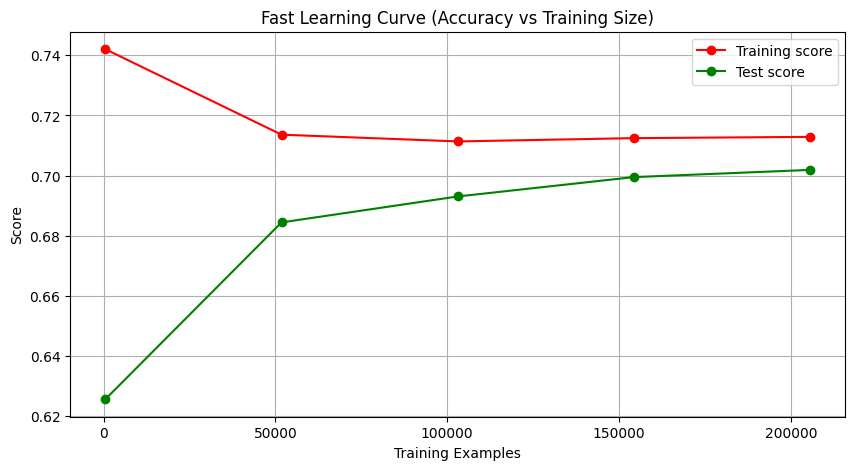

<module 'matplotlib.pyplot' from 'c:\\Users\\AsreRayaneh\\miniconda3\\envs\\rahdari\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [36]:
import numpy as np
learning_curve(model=model)

#### XGboost

In [40]:
from xgboost import XGBClassifier
for col in features:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data['MBF_category'] = pd.qcut(data['MBF'], q=3, labels=[0, 1, 2])
# 1. Define Features (X) and Target (y)
# Ensure you use the 'Failure_Class' we created earlier (0, 1, 2)
X = data[features]
y = data['MBF_category']

# 2. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize and Train the Model
xgb_model = XGBClassifier(
    n_estimators=1000,        # Increased, but early_stopping will find the real limit
    learning_rate=0.05,
    max_depth=4,              # REDUCED: Prevents trees from being too complex
    subsample=0.8,           # NEW: Only uses 80% of rows per tree
    colsample_bytree=0.8,     # NEW: Only uses 80% of features per tree
    gamma=1,                 # NEW: Minimum loss reduction required for a split
    tree_method='hist',
    random_state=42,
)

xgb_model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = xgb_model.predict(X_test)

# 5. Validation Scores
print("--- Validation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Validation Metrics ---
Accuracy Score: 69.57%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79     17131
           1       0.58      0.59      0.58     17133
           2       0.70      0.73      0.72     17128

    accuracy                           0.70     51392
   macro avg       0.70      0.70      0.70     51392
weighted avg       0.70      0.70      0.70     51392



In [41]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = xgb_model.predict(X_train)

# Calculate scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")
print(f"Gap: {train_acc - test_acc:.2%}")

Training Accuracy: 70.54%
Testing Accuracy: 69.57%
Gap: 0.98%


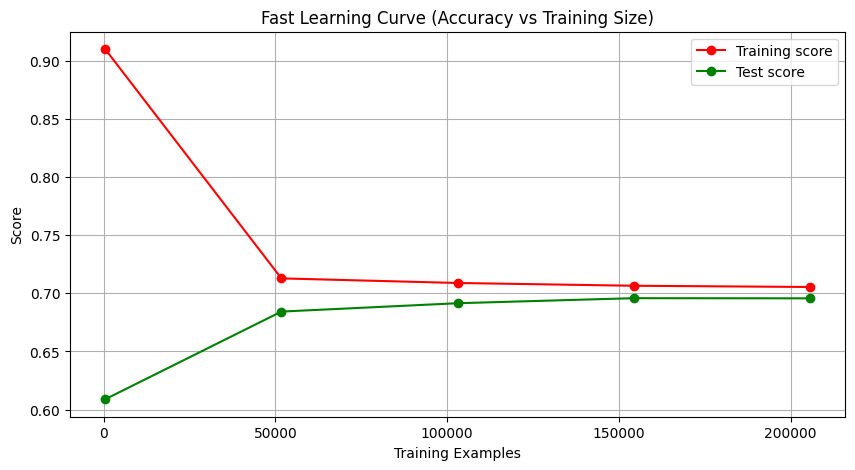

<module 'matplotlib.pyplot' from 'c:\\Users\\AsreRayaneh\\miniconda3\\envs\\rahdari\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [42]:
learning_curve(model=xgb_model)

### aproaches for calculate the optimal k for quntile cuts

In [43]:
import numpy as np

# Calculate IQR and n
q75, q25 = np.percentile(data['MBF'], [75 ,25])
iqr = q75 - q25
n = len(data['MBF'])

# Calculate bin width and number of bins
bin_width = 2 * iqr / (n ** (1/3))
optimal_q = int((data['MBF'].max() - data['MBF'].min()) / bin_width)

print(f"Statistically suggested q: {optimal_q}")

Statistically suggested q: 2173


In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test different k values on a sample of your data (for speed)
sample_mbf = data['MBF'].sample(10000).values.reshape(-1, 1)
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(sample_mbf)
    score = silhouette_score(sample_mbf, kmeans.labels_)
    print(f"k={k}, Silhouette Score: {score:.4f}")

k=2, Silhouette Score: 0.8019
k=3, Silhouette Score: 0.7783
k=4, Silhouette Score: 0.7173
k=5, Silhouette Score: 0.6921
k=6, Silhouette Score: 0.6542
k=7, Silhouette Score: 0.6543
k=8, Silhouette Score: 0.6281
k=9, Silhouette Score: 0.6253
